# Notebook 03: Equilibrium Analysis

## Negative Frequency-Dependent Selection (NFDS)

Under **self-incompatibility (SI)** at the S-locus, alleles experience **negative frequency-dependent selection**:

- **Rare alleles** confer a mating advantage — their carriers are compatible with a larger fraction of the population
- **Common alleles** are disadvantaged — more potential mates reject pollen carrying them

This is fundamentally different from classical Hardy-Weinberg equilibrium, which assumes no selection. Here, **selection is the driving force**: NFDS naturally pushes allele frequencies toward equality without any intervention.

### NFDS equilibrium target
The expected equilibrium under NFDS is **equal frequency of all S-alleles**:
- For `n` alleles: target frequency = `1/n` for each allele
- Real populations deviate from this due to genetic drift, bottlenecks, and founder effects
- In large undisturbed populations, NFDS alone will restore equilibrium over time
- In small or fragmented populations (like *L. papilliferum*), strategic crossing can **accelerate** what nature already does

### Distance metrics
We measure how far a population is from NFDS equilibrium using:
1. **Frequency variance**: `Var(frequencies)` — 0 at equilibrium
2. **Chi-squared statistic**: `Σ (observed - expected)² / expected`
3. **KL divergence**: `Σ p(x) log(p(x)/q(x))` where `q` is the uniform target

This notebook computes these metrics and simulates how crossing strategies affect allele frequency convergence.

In [1]:
import itertools
import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ---------------------------------------------------------------------------
# Utility functions from Notebooks 01 & 02
# ---------------------------------------------------------------------------

def canonical(alleles):
    """Return the canonical (sorted tuple) form of a genotype."""
    return tuple(sorted(alleles))

def allele_frequencies(population, allele_pool=None):
    """Compute allele frequencies (proportion of each S-allele in the population)."""
    counts = Counter()
    total = 0
    for genotype in population:
        for allele in genotype:
            counts[allele] += 1
            total += 1
    freqs = {a: counts[a] / total for a in counts}
    if allele_pool is not None:
        for a in allele_pool:
            if a not in freqs:
                freqs[a] = 0.0
    return dict(sorted(freqs.items()))

def form_gametes(genotype):
    """Return all C(4,2)=6 diploid gametes from a tetraploid genotype."""
    return list(itertools.combinations(genotype, 2))

def is_compatible(maternal_genotype, pollen_gamete):
    """Check SI compatibility: True if pollen shares no alleles with maternal plant."""
    maternal_alleles = set(maternal_genotype)
    return not any(a in maternal_alleles for a in pollen_gamete)

def cross(parent_a, parent_b):
    """Compute offspring genotype probabilities for a directed cross (maternal x pollen)."""
    maternal_gametes = form_gametes(parent_a)
    paternal_gametes = form_gametes(parent_b)
    compatible_paternal = [g for g in paternal_gametes if is_compatible(parent_a, g)]
    if not compatible_paternal:
        return {}
    offspring_counts = Counter()
    total_combinations = len(maternal_gametes) * len(compatible_paternal)
    for mg in maternal_gametes:
        for pg in compatible_paternal:
            offspring_genotype = canonical(mg + pg)
            offspring_counts[offspring_genotype] += 1
    return {g: count / total_combinations for g, count in sorted(offspring_counts.items())}

def crossing_compatibility(parent_a, parent_b):
    """Fraction of pollen gametes that pass SI (0.0 = incompatible, 1.0 = fully compatible)."""
    paternal_gametes = form_gametes(parent_b)
    compatible = sum(1 for g in paternal_gametes if is_compatible(parent_a, g))
    return compatible / len(paternal_gametes)

print("Utilities loaded.")

Utilities loaded.


In [2]:
# ---------------------------------------------------------------------------
# Equilibrium analysis functions
# ---------------------------------------------------------------------------

def target_frequencies(allele_pool):
    """Return the uniform (equilibrium) frequency distribution.

    Under NFDS, the expected equilibrium is equal frequency for all S-alleles:
    each allele at 1/n where n is the total number of distinct alleles.
    """
    n = len(allele_pool)
    return {a: 1.0 / n for a in sorted(allele_pool)}


def distance_from_equilibrium(population, allele_pool):
    """Compute multiple distance metrics from equal-frequency equilibrium.

    Three complementary metrics measure how far a population deviates
    from the NFDS equilibrium (uniform allele frequencies):

    - Variance: measures the spread of allele frequencies around the mean.
      Biologically, higher variance means some alleles dominate while others
      are rare — exactly the imbalance NFDS acts against. Zero at equilibrium.

    - Chi-squared: standard goodness-of-fit statistic comparing observed
      frequencies to the expected uniform distribution. Useful because it
      has a known statistical distribution for hypothesis testing. Weights
      deviations by expected frequency, so rare-allele deviations count more.

    - KL divergence: information-theoretic measure of how the observed
      distribution differs from uniform. Quantifies the "information lost"
      by assuming equilibrium when the population is actually skewed.
      Always >= 0, equals 0 only at perfect uniformity.

    Returns
    -------
    dict with keys: 'variance', 'chi_squared', 'kl_divergence'
    """
    freqs = allele_frequencies(population, allele_pool)
    n = len(allele_pool)
    target = 1.0 / n
    freq_values = np.array([freqs[a] for a in sorted(allele_pool)])

    variance = float(np.var(freq_values))
    chi_squared = float(np.sum((freq_values - target) ** 2 / target))

    # KL divergence: D_KL(observed || uniform)
    # Add small epsilon to avoid log(0) for alleles absent from the population
    eps = 1e-12
    freq_safe = np.maximum(freq_values, eps)
    kl_div = float(np.sum(freq_safe * np.log(freq_safe / target)))

    return {
        "variance": variance,
        "chi_squared": chi_squared,
        "kl_divergence": kl_div,
    }


print("Equilibrium functions defined: target_frequencies, distance_from_equilibrium")

Equilibrium functions defined: target_frequencies, distance_from_equilibrium


In [3]:
# ---------------------------------------------------------------------------
# Population simulation
# ---------------------------------------------------------------------------

def sample_offspring(parent_a, parent_b):
    """Sample a single offspring genotype from a cross (returns None if incompatible).

    Draws one offspring from the probability distribution computed by cross().
    This stochastic sampling mirrors real reproduction where each mating event
    produces one individual, not the full distribution.
    """
    offspring_dist = cross(parent_a, parent_b)
    if not offspring_dist:
        return None
    genotypes = list(offspring_dist.keys())
    probs = list(offspring_dist.values())
    idx = np.random.choice(len(genotypes), p=probs)
    return genotypes[idx]


def simulate_generation(population, n_offspring=None, crossing_plan=None):
    """Simulate one generation of crossing to produce the next generation.

    Two mating modes:
    1. Random mating (crossing_plan=None): pairs are chosen uniformly at random.
       This lets NFDS operate naturally — rare-allele carriers are more likely
       to find compatible mates, so rare alleles increase in frequency.
    2. Directed crossing (crossing_plan provided): crosses are sampled
       proportional to their assigned weights. Higher-weight crosses are
       attempted more often, steering the population toward desired frequencies.

    The retry mechanism (up to 20x n_offspring attempts) handles the fact
    that some randomly selected pairs may be SI-incompatible and produce
    no offspring. The loop continues until enough offspring are generated.

    Parameters
    ----------
    population : list[tuple]
        Current generation genotypes.
    n_offspring : int or None
        Number of offspring to produce (defaults to population size).
    crossing_plan : list[tuple[int, int, float]] or None
        If provided, a list of (maternal_idx, paternal_idx, weight) triples.
        Crosses are sampled proportional to weight.
        If None, random compatible mating.

    Returns
    -------
    list[tuple]
        The next generation's genotypes.
    """
    if n_offspring is None:
        n_offspring = len(population)

    next_gen = []

    if crossing_plan is not None:
        # Weighted crossing: sample crosses proportional to plan weights.
        # Higher-weight crosses are attempted more frequently, allowing
        # the optimization to steer allele frequencies.
        indices = list(range(len(crossing_plan)))
        weights = np.array([w for _, _, w in crossing_plan])
        weights = weights / weights.sum()

        attempts = 0
        while len(next_gen) < n_offspring and attempts < n_offspring * 20:
            idx = np.random.choice(indices, p=weights)
            mi, pi, _ = crossing_plan[idx]
            child = sample_offspring(population[mi], population[pi])
            if child is not None:
                next_gen.append(child)
            attempts += 1
    else:
        # Random mating: pick two distinct individuals uniformly at random.
        # SI-incompatible pairs produce no offspring and we retry.
        attempts = 0
        n = len(population)
        while len(next_gen) < n_offspring and attempts < n_offspring * 20:
            i, j = random.sample(range(n), 2)
            child = sample_offspring(population[i], population[j])
            if child is not None:
                next_gen.append(child)
            attempts += 1

    return next_gen


def compute_next_gen_frequencies(population, allele_pool, crossing_plan=None):
    """Compute expected allele frequencies after one generation of crossing."""
    next_gen = simulate_generation(population, crossing_plan=crossing_plan)
    return allele_frequencies(next_gen, allele_pool)


print("Simulation functions defined: sample_offspring, simulate_generation, compute_next_gen_frequencies")

Simulation functions defined: sample_offspring, simulate_generation, compute_next_gen_frequencies


## Demo: Natural Convergence Under Random Mating

Starting from a **skewed population** (some alleles overrepresented), we simulate random compatible mating for several generations. Because of NFDS, rare alleles have a natural mating advantage — we expect allele frequencies to converge toward equality even without directed intervention. This demonstrates the self-correcting nature of frequency-dependent selection at the S-locus.

In [4]:
np.random.seed(42)
random.seed(42)

allele_pool = list(range(1, 9))  # 8 S-alleles

# Skewed starting population: alleles S1-S3 are overrepresented (common founders),
# while S7-S8 are rare (recently introduced or nearly lost to drift).
# This mimics a bottlenecked population of L. papilliferum where founder effects
# have created unequal allele frequencies — the starting point for our simulation.
population = [
    (1, 1, 2, 3),
    (1, 2, 2, 4),
    (1, 1, 3, 5),
    (2, 2, 3, 4),
    (1, 2, 5, 6),
    (1, 3, 4, 5),
    (2, 3, 3, 6),
    (1, 1, 2, 6),
    (1, 2, 4, 4),
    (2, 3, 5, 6),
    (1, 1, 4, 5),
    (1, 2, 3, 3),
    (2, 2, 5, 6),
    (1, 3, 4, 6),
    (1, 2, 2, 5),
    (1, 1, 3, 7),
    (2, 4, 5, 8),
    (1, 3, 6, 7),
    (2, 3, 4, 8),
    (1, 2, 7, 8),
]

print(f"Population size: {len(population)}")
print(f"Initial allele frequencies:")
initial_freqs = allele_frequencies(population, allele_pool)
for a, f in initial_freqs.items():
    print(f"  S{a}: {f:.4f}")

print(f"\nInitial distance from equilibrium:")
d = distance_from_equilibrium(population, allele_pool)
for metric, val in d.items():
    print(f"  {metric}: {val:.6f}")

Population size: 20
Initial allele frequencies:
  S1: 0.2375
  S2: 0.2250
  S3: 0.1625
  S4: 0.1125
  S5: 0.1000
  S6: 0.0875
  S7: 0.0375
  S8: 0.0375

Initial distance from equilibrium:
  variance: 0.005195
  chi_squared: 0.332500
  kl_divergence: 0.171652


In [5]:
# Simulate random mating over 30 generations to observe natural NFDS convergence.
# Each generation: the current population mates randomly, producing n_offspring
# individuals for the next generation. We track three distance metrics and
# per-allele frequencies at each generation to visualize the convergence trajectory.
n_generations = 30
pop_size = len(population)

# Track distance metrics and per-allele frequencies over generations
history = {
    "generation": [],
    "variance": [],
    "chi_squared": [],
    "kl_divergence": [],
}
freq_history = {a: [] for a in allele_pool}

current_pop = list(population)

for gen in range(n_generations + 1):
    # Record current state before advancing
    d = distance_from_equilibrium(current_pop, allele_pool)
    history["generation"].append(gen)
    history["variance"].append(d["variance"])
    history["chi_squared"].append(d["chi_squared"])
    history["kl_divergence"].append(d["kl_divergence"])

    freqs = allele_frequencies(current_pop, allele_pool)
    for a in allele_pool:
        freq_history[a].append(freqs[a])

    # Advance to next generation (except on the final iteration)
    if gen < n_generations:
        current_pop = simulate_generation(current_pop, n_offspring=pop_size)

print(f"Simulated {n_generations} generations of random mating.")
print(f"\nFinal distance metrics:")
for metric in ["variance", "chi_squared", "kl_divergence"]:
    print(f"  {metric}: {history[metric][0]:.6f} -> {history[metric][-1]:.6f}")

Simulated 30 generations of random mating.

Final distance metrics:
  variance: 0.005195 -> 0.000664
  chi_squared: 0.332500 -> 0.042500
  kl_divergence: 0.171652 -> 0.022461


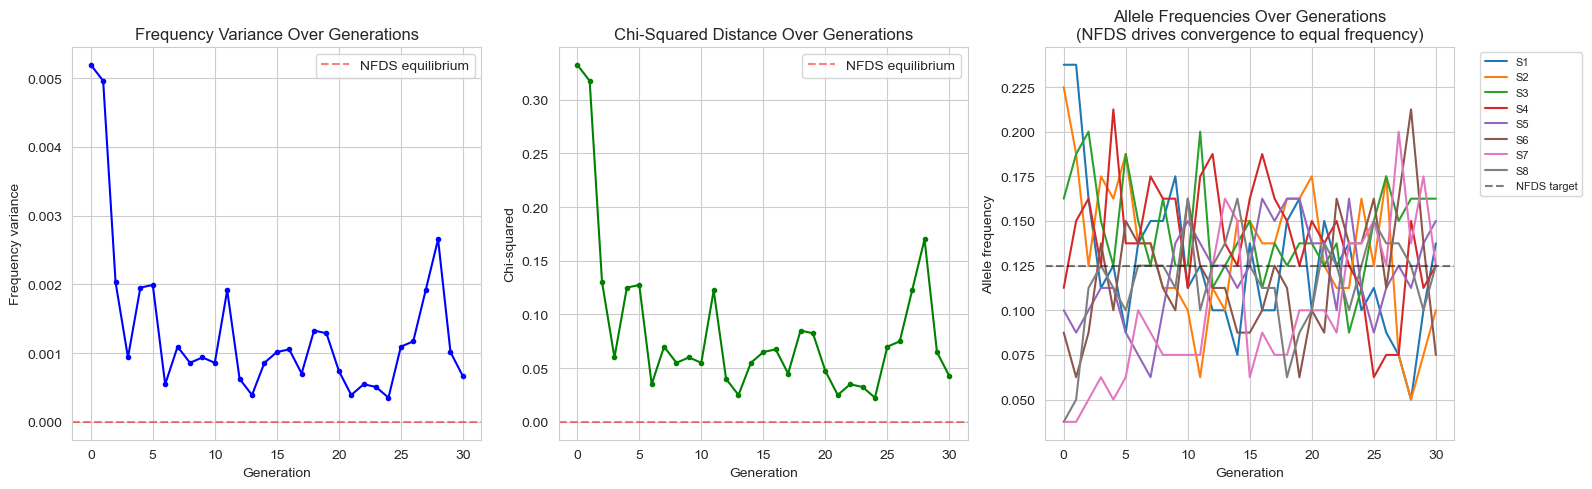

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Frequency variance — overall measure of allele frequency imbalance.
# Decreasing variance means frequencies are becoming more uniform (converging).
axes[0].plot(history["generation"], history["variance"], "b-o", markersize=3)
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Frequency variance")
axes[0].set_title("Frequency Variance Over Generations")
axes[0].axhline(y=0, color="red", linestyle="--", alpha=0.5, label="NFDS equilibrium")
axes[0].legend()

# Plot 2: Chi-squared — goodness-of-fit against uniform distribution.
# Approaching 0 means allele frequencies match the equilibrium target.
axes[1].plot(history["generation"], history["chi_squared"], "g-o", markersize=3)
axes[1].set_xlabel("Generation")
axes[1].set_ylabel("Chi-squared")
axes[1].set_title("Chi-Squared Distance Over Generations")
axes[1].axhline(y=0, color="red", linestyle="--", alpha=0.5, label="NFDS equilibrium")
axes[1].legend()

# Plot 3: Individual allele frequency trajectories.
# Under NFDS, rare alleles (low initial frequency) should increase and common
# alleles should decrease, all converging toward the 1/n target line.
target = 1.0 / len(allele_pool)
for a in allele_pool:
    axes[2].plot(history["generation"], freq_history[a], label=f"S{a}", linewidth=1.5)
axes[2].axhline(y=target, color="black", linestyle="--", alpha=0.5, label="NFDS target")
axes[2].set_xlabel("Generation")
axes[2].set_ylabel("Allele frequency")
axes[2].set_title("Allele Frequencies Over Generations\n(NFDS drives convergence to equal frequency)")
axes[2].legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()